In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lanechangevideo/Lane_C_Video.mp4
/kaggle/input/processed-tracking-data-static-cen300/processed_combined_tracking_data.csv
/kaggle/input/0212-cropped-video-cen300-45s/0212_cropped.mp4
/kaggle/input/141-conflict-zone-polygons-cen300-via/141_conflict_zones_CEN300_PET.csv
/kaggle/input/sdtatt-eval/__results__.html
/kaggle/input/sdtatt-eval/__notebook__.ipynb
/kaggle/input/sdtatt-eval/__output__.json
/kaggle/input/sdtatt-eval/custom.css
/kaggle/input/sdtatt-eval/vehicle_trajectory_prediction/requirments.txt
/kaggle/input/sdtatt-eval/vehicle_trajectory_prediction/.gitignore
/kaggle/input/sdtatt-eval/vehicle_trajectory_prediction/main.py
/kaggle/input/sdtatt-eval/vehicle_trajectory_prediction/README.md
/kaggle/input/sdtatt-eval/vehicle_trajectory_prediction/detection_tracking_inference.py
/kaggle/input/sdtatt-eval/vehicle_trajectory_prediction/PET.ipynb
/kaggle/input/sdtatt-eval/vehicle_trajectory_prediction/detection_tracking_inference.ipynb
/kaggle/input/sdtatt-eval/vehicle_tr

In [2]:
import pandas as pd
import numpy as np
import cv2
import json
from shapely.geometry import Polygon, Point

class PETPipeline:
    def __init__(self, tracking_path, zone_path, video_path):
        self.tracking_path = tracking_path
        self.zone_path = zone_path
        self.video_path = video_path
        self.df = None
        self.zone_df = None
        self.conflict_zones = []
        self.conflict_log = []
        self.pet_df = None
        self.width = None
        self.height = None
        self.fps = None

    def load_data(self):
        self.df = pd.read_csv(self.tracking_path)
        self.df.rename(columns={
            'timestamp': 'Time',
            'frame_number': 'Frame_ID',
            'vehicle_id': 'Vehicle_ID',
            'x': 'X_central',
            'y': 'Y_central',
            'x1': 'X1_boundary',
            'y1': 'Y1_boundary',
            'x2': 'X3_boundary',
            'y2': 'Y3_boundary'
        }, inplace=True)

        self.zone_df = pd.read_csv(self.zone_path)

    def build_conflict_zones(self):
        for _, row in self.zone_df.iterrows():
            shape = json.loads(row['region_shape_attributes'].replace("'", '"'))
            coords = list(zip(shape['all_points_x'], shape['all_points_y']))
            polygon = Polygon(coords)
            self.conflict_zones.append({
                'name': row['zone_id'],
                'polygon': polygon
            })

    def map_conflict_zones(self):
        def get_zone_id(row):
            pt = Point(row['X_central'], row['Y_central'])
            for zone in self.conflict_zones:
                if zone['polygon'].contains(pt):
                    return zone['name']
            return None

        self.df['Conflict_Zone_ID'] = self.df.apply(get_zone_id, axis=1)
        self.df['In_Conflict_Zone'] = self.df['Conflict_Zone_ID'].notnull()
        self.df['Conflict_Zone_ID'] = self.df['Conflict_Zone_ID'].fillna(-1)

    def detect_conflicts(self):
        entries = self.df[self.df['In_Conflict_Zone']]
        for vid in entries['Vehicle_ID'].unique():
            track = entries[entries['Vehicle_ID'] == vid].sort_values('Time')
            for zid in track['Conflict_Zone_ID'].unique():
                zone_track = track[track['Conflict_Zone_ID'] == zid]
                in_zone = False
                entry_time = None

                for i, (_, row) in enumerate(zone_track.iterrows()):
                    if not in_zone:
                        entry_time = row['Time']
                        in_zone = True
                    if in_zone and (i == len(zone_track) - 1 or zone_track.iloc[i+1]['Conflict_Zone_ID'] != zid):
                        exit_time = row['Time']
                        self.conflict_log.append({
                            'Vehicle_ID': vid,
                            'Conflict_Zone_ID': zid,
                            'entry_time': entry_time,
                            'exit_time': exit_time,
                            'duration': exit_time - entry_time
                        })
                        in_zone = False

    def compute_pet(self):
        pet_data = []
        df_log = pd.DataFrame(self.conflict_log)
        if df_log.empty:
            self.pet_df = pd.DataFrame()
            return

        df_log = df_log.sort_values(['Conflict_Zone_ID', 'exit_time'])
        for zid in df_log['Conflict_Zone_ID'].unique():
            zone_df = df_log[df_log['Conflict_Zone_ID'] == zid].reset_index(drop=True)
            for i in range(1, len(zone_df)):
                prev = zone_df.iloc[i - 1]
                curr = zone_df.iloc[i]
                pet = curr['entry_time'] - prev['exit_time']
                pet_data.append({
                    'zone_id': zid,
                    'leading_vehicle': prev['Vehicle_ID'],
                    'following_vehicle': curr['Vehicle_ID'],
                    'pet': pet
                })

        self.pet_df = pd.DataFrame(pet_data)
        self.pet_df['risk_category'] = self.pet_df['pet'].apply(self.categorize_pet)

    def categorize_pet(self, pet):
        if pet <= 0:
            return 'Near-Miss'
        elif pet <= 1.5:
            return 'High Risk'
        elif pet <= 3.0:
            return 'Moderate Risk'
        elif pet <= 5.0:
            return 'Low Risk'
        else:
            return 'Safe'

    def prepare_video_metadata(self):
        cap = cv2.VideoCapture(self.video_path)
        self.width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        self.fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()

    def generate_heatmap(self):
        heatmap = np.zeros((self.height, self.width), dtype=np.float32)
        weights = {
            'Near-Miss': 1.0**2,
            'High Risk': 0.8**2,
            'Moderate Risk': 0.6**2,
            'Low Risk': 0.4**2,
            'Safe': 0.2**2
        }

        for _, row in self.pet_df.iterrows():
            lead = self.df[self.df['Vehicle_ID'] == row['leading_vehicle']]
            follow = self.df[self.df['Vehicle_ID'] == row['following_vehicle']]
            common = np.intersect1d(lead['Frame_ID'], follow['Frame_ID'])

            for fid in common:
                l = lead[lead['Frame_ID'] == fid]
                f = follow[follow['Frame_ID'] == fid]
                if l.empty or f.empty:
                    continue

                for box in [l, f]:
                    x = int(box['X_central'].values[0])
                    y = int(box['Y_central'].values[0])
                    cv2.circle(heatmap, (x, y), 5, weights[row['risk_category']], -1)

        heatmap = cv2.GaussianBlur(heatmap, (0, 0), sigmaX=10, sigmaY=10)
        heatmap = np.clip(heatmap, 0.05, 1.0)
        heatmap = (heatmap - 0.05) / (1.0 - 0.05)
        return heatmap

    def generate_cumulative_heatmap(self, up_to_time):
        dynamic_heatmap = np.zeros((self.height, self.width), dtype=np.float32)
        weights = {
            'Near-Miss': 1.0**2,
            'High Risk': 0.8**2,
            'Moderate Risk': 0.6**2,
            'Low Risk': 0.4**2,
            'Safe': 0.2**2
        }
    
        # Only consider PET events that have occurred up to this time
        for _, row in self.pet_df.iterrows():
            # Get the entry time of the following vehicle into the zone
            df_log = pd.DataFrame(self.conflict_log)
            follow_entry = df_log[
                (df_log['Vehicle_ID'] == row['following_vehicle']) &
                (df_log['Conflict_Zone_ID'] == row['zone_id'])
            ]
            if not follow_entry.empty and follow_entry.iloc[0]['entry_time'] > up_to_time:
                continue  #hasn't happened yet
    
            lead = self.df[self.df['Vehicle_ID'] == row['leading_vehicle']]
            follow = self.df[self.df['Vehicle_ID'] == row['following_vehicle']]
            common = np.intersect1d(lead['Frame_ID'], follow['Frame_ID'])
    
            for fid in common:
                frame_time = self.df[self.df['Frame_ID'] == fid]['Time'].iloc[0]
                if frame_time > up_to_time:
                    continue
                l = lead[lead['Frame_ID'] == fid]
                f = follow[follow['Frame_ID'] == fid]
                if l.empty or f.empty:
                    continue
                for box in [l, f]:
                    x = int(box['X_central'].values[0])
                    y = int(box['Y_central'].values[0])
                    cv2.circle(dynamic_heatmap, (x, y), 5, weights[row['risk_category']], -1)
    
        dynamic_heatmap = cv2.GaussianBlur(dynamic_heatmap, (0, 0), sigmaX=10, sigmaY=10)
        dynamic_heatmap = np.clip(dynamic_heatmap, 0.05, 1.0)
        dynamic_heatmap = (dynamic_heatmap - 0.05) / (1.0 - 0.05)
        return dynamic_heatmap


    def run(self):
        self.load_data()
        self.build_conflict_zones()
        self.map_conflict_zones()
        self.detect_conflicts()
        self.compute_pet()
        self.prepare_video_metadata()

In [3]:
pipeline = PETPipeline(
    tracking_path="/kaggle/input/processed-tracking-data-static-cen300/processed_combined_tracking_data.csv",
    zone_path="/kaggle/input/141-conflict-zone-polygons-cen300-via/141_conflict_zones_CEN300_PET.csv",
    video_path="/kaggle/input/0212-cropped-video-cen300-45s/0212_cropped.mp4"
)

pipeline.run()
heatmap = pipeline.generate_heatmap()

In [4]:
cap = cv2.VideoCapture("/kaggle/input/lanechangevideo/Lane_C_Video.mp4")
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output_dynamic_heatmap.mp4", fourcc, fps, (width, height))

frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Get the current time for this frame
    current_time = frame_idx / fps

    # Generate cumulative heatmap up to this time
    dynamic_heatmap = pipeline.generate_cumulative_heatmap(current_time)
    normalized_heatmap = cv2.normalize(dynamic_heatmap, None, 0, 255, cv2.NORM_MINMAX)
    colored_heatmap = cv2.applyColorMap(normalized_heatmap.astype(np.uint8), cv2.COLORMAP_JET)

    if colored_heatmap.shape[:2] != frame.shape[:2]:
        colored_heatmap = cv2.resize(colored_heatmap, (frame.shape[1], frame.shape[0]))

    alpha = 0.6

    def draw_heatmap_legend(frame, x=20, y=5, width=20, height=20):
        legend_colors = {
        'Near-Miss': (0, 0, 255),         # Red
        'High Risk': (0, 69, 255),        # Orange-Red
        'Moderate Risk': (0, 255, 255),   # Yellow
        'Low Risk': (255, 255, 0),        # Cyan
        'Safe': (255, 0, 0)               # Blue
        }
    
        gap = height + 5  # vertical spacing
        start_y = y
    
        for label, color in legend_colors.items():
            end_y = start_y + height
            cv2.rectangle(frame, (x, start_y), (x + width, end_y), color, -1)
            cv2.putText(frame, label, (x + width + 10, start_y + height // 2 + 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
            start_y += gap
    
        return frame
    
    overlay = cv2.addWeighted(colored_heatmap, alpha, frame, 1 - alpha, 0)
    overlay = draw_heatmap_legend(overlay)  # Add legend

    out.write(overlay)
    frame_idx += 1

cap.release()
out.release()
cv2.destroyAllWindows()

In [5]:
pipeline.zone_df

,zone_id,region_shape_attributes
0,1,"{""name"":""polyline"",""all_points_x"":[388,414,414..."
1,2,"{""name"":""polyline"",""all_points_x"":[415,415,442..."
2,3,"{""name"":""polyline"",""all_points_x"":[415,415,442..."
3,4,"{""name"":""polyline"",""all_points_x"":[443,443,470..."
4,5,"{""name"":""polyline"",""all_points_x"":[388,414,414..."
...,...,...
136,137,"{""name"":""polyline"",""all_points_x"":[63,83,83,63..."
137,138,"{""name"":""polyline"",""all_points_x"":[63,84,84,63..."
138,139,"{""name"":""polyline"",""all_points_x"":[39,60,60,39..."
139,140,"{""name"":""polyline"",""all_points_x"":[39,61,61,39..."


In [6]:
pipeline.conflict_zones[:10]

[{'name': 1,
  'polygon': <POLYGON ((388 246, 414 246, 414 260, 388 260, 388 246))>},
 {'name': 2,
  'polygon': <POLYGON ((415 246, 415 260, 442 260, 442 246, 415 246))>},
 {'name': 3,
  'polygon': <POLYGON ((415 246, 415 260, 442 260, 442 246, 415 246))>},
 {'name': 4,
  'polygon': <POLYGON ((443 246, 443 260, 470 260, 470 246, 443 246))>},
 {'name': 5,
  'polygon': <POLYGON ((388 243, 414 244, 414 230, 388 229, 388 243))>},
 {'name': 6,
  'polygon': <POLYGON ((415 230, 442 230, 442 244, 415 244, 415 230))>},
 {'name': 7,
  'polygon': <POLYGON ((443 230, 470 230, 470 244, 443 244, 443 230))>},
 {'name': 8,
  'polygon': <POLYGON ((471 230, 471 244, 497 244, 497 230, 471 230))>},
 {'name': 9,
  'polygon': <POLYGON ((471 246, 497 246, 497 260, 471 260, 471 246))>},
 {'name': 10,
  'polygon': <POLYGON ((498 230, 526 230, 526 244, 498 244, 498 230))>}]

In [7]:
import cv2

cap = cv2.VideoCapture('/kaggle/input/0212-cropped-video-cen300-45s/0212_cropped.mp4')
ret, frame = cap.read()  # Read the first frame
cv2.imwrite("random_frame.jpg", frame)  # Save the frame

True

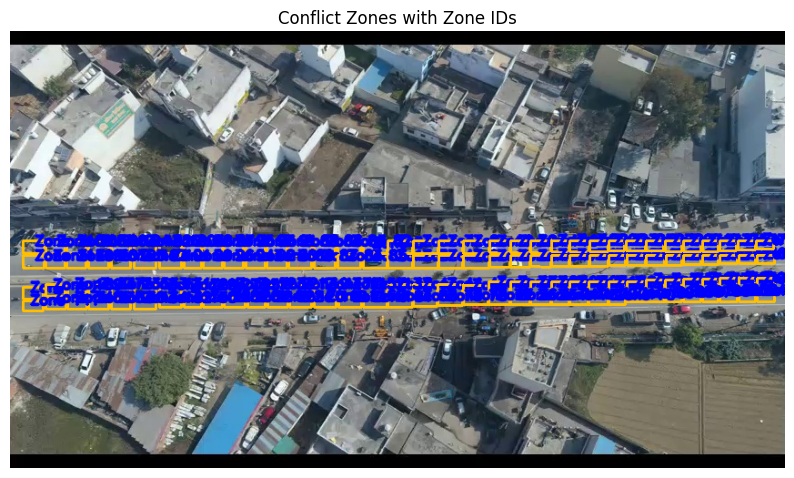

In [8]:
import matplotlib.pyplot as plt

# Load image
image_path = '/kaggle/working/random_frame.jpg'
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw polygons and overlay zone IDs
for idx, row in pipeline.zone_df.iterrows():
    try:
        shape = json.loads(row['region_shape_attributes'])  # Properly parsed

        all_x = shape['all_points_x']
        all_y = shape['all_points_y']
        points = list(zip(all_x, all_y))
        pts_np = np.array(points, np.int32).reshape((-1, 1, 2))

        # Draw polygon
        cv2.polylines(image, [pts_np], isClosed=True, color=(255, 191, 0), thickness=2)

        # Put zone_id text at the centroid
        centroid_x = int(np.mean(all_x))
        centroid_y = int(np.mean(all_y))
        zone_id = str(row['zone_id'])

        cv2.putText(image, f"Zone {zone_id}", (centroid_x, centroid_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)

    except Exception as e:
        print(f"⚠️ Error parsing row {idx}: {e}")

# Show result
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.title("Conflict Zones with Zone IDs")
plt.axis('off')
plt.show()


In [9]:
pipeline.pet_df = pd.DataFrame(pipeline.pet_df)
pipeline.pet_df

,zone_id,leading_vehicle,following_vehicle,pet,risk_category
0,1.0,3.0,1.0,1.433333,High Risk
1,1.0,1.0,66.0,7.333333,Safe
2,1.0,66.0,184.0,7.833333,Safe
3,1.0,184.0,321.0,15.933333,Safe
4,1.0,321.0,320.0,5.266667,Safe
...,...,...,...,...,...
351,139.0,279.0,346.0,15.733333,Safe
352,140.0,28.0,5.0,1.466667,High Risk
353,140.0,5.0,31.0,5.500000,Safe
354,140.0,31.0,218.0,17.833333,Safe


In [10]:
pipeline.pet_df['risk_category'].value_counts()

risk_category
Safe             190
Moderate Risk     55
Low Risk          54
High Risk         51
Near-Miss          6
Name: count, dtype: int64

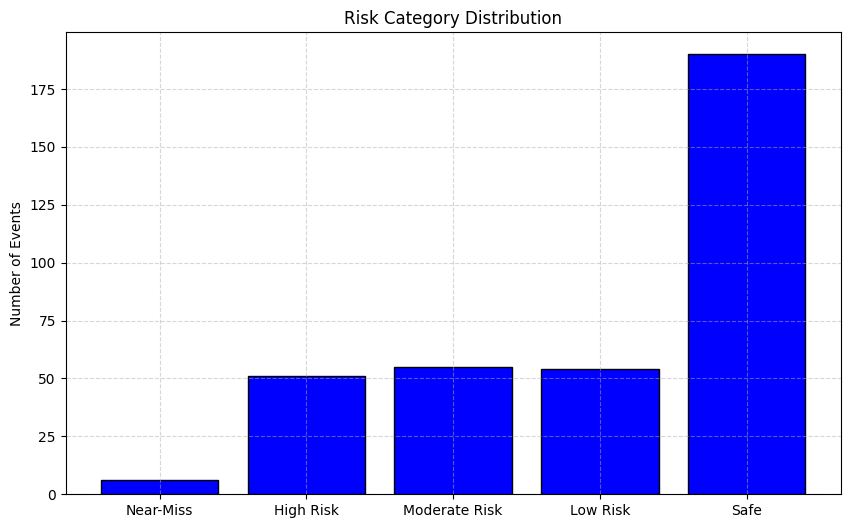

In [11]:
import matplotlib.pyplot as plt

risk_counts = pipeline.pet_df['risk_category'].value_counts().reindex([
    'Near-Miss', 'High Risk', 'Moderate Risk', 'Low Risk', 'Safe'
], fill_value=0)

plt.figure(figsize=(10, 6))
plt.bar(risk_counts.index, risk_counts.values, color='blue', edgecolor='black')
plt.title('Risk Category Distribution')
plt.ylabel('Number of Events')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

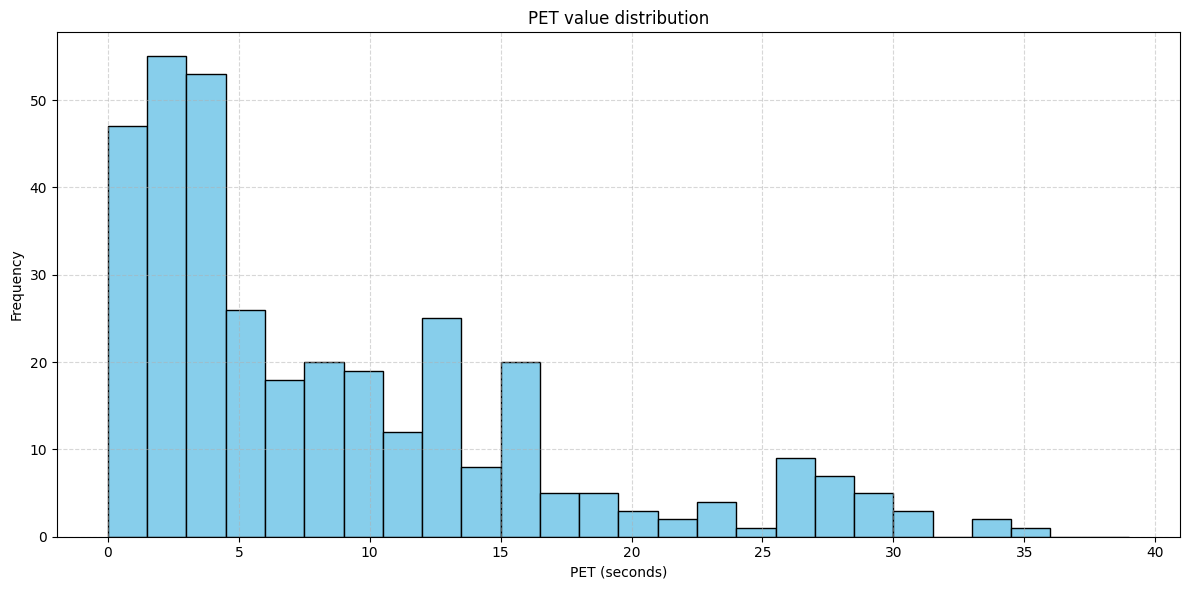

In [12]:
plt.figure(figsize=(12, 6))
bins = np.arange(0, pipeline.pet_df['pet'].max() + 5, 1.5)

plt.hist(pipeline.pet_df['pet'], bins=bins, color='skyblue', edgecolor='black')
plt.xlabel('PET (seconds)')
plt.ylabel('Frequency')
plt.title('PET value distribution')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
for p in [25, 50, 75, 90]:
    print(f"{p}th percentile PET: {np.percentile(pipeline.pet_df['pet'], p):.2f} seconds")

25th percentile PET: 2.47 seconds
50th percentile PET: 5.70 seconds
75th percentile PET: 12.47 seconds
90th percentile PET: 19.67 seconds


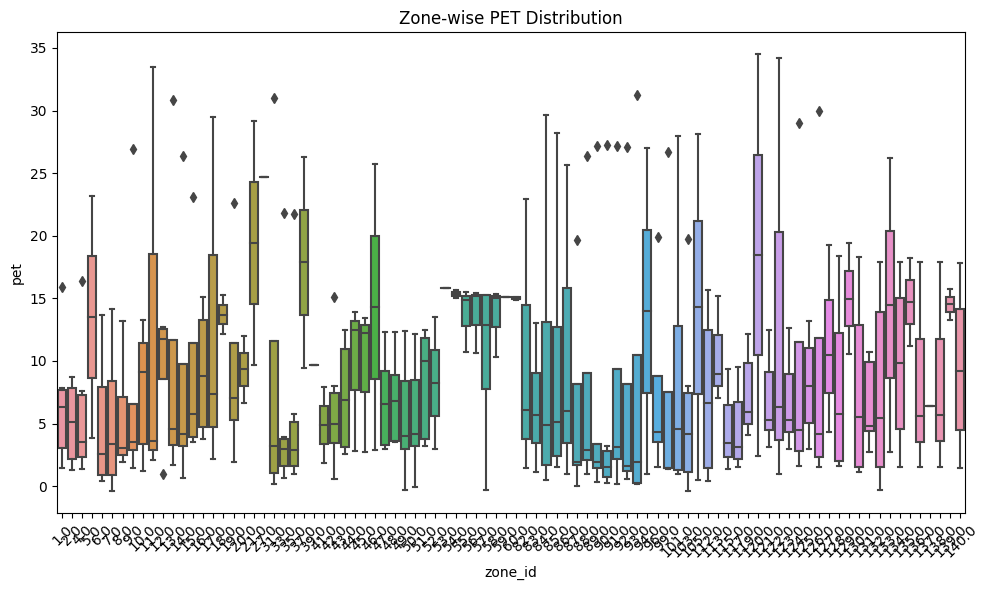

In [14]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='zone_id', y='pet', data=pipeline.pet_df)
plt.xticks(rotation=45)
plt.title("Zone-wise PET Distribution")
plt.tight_layout()
plt.show()

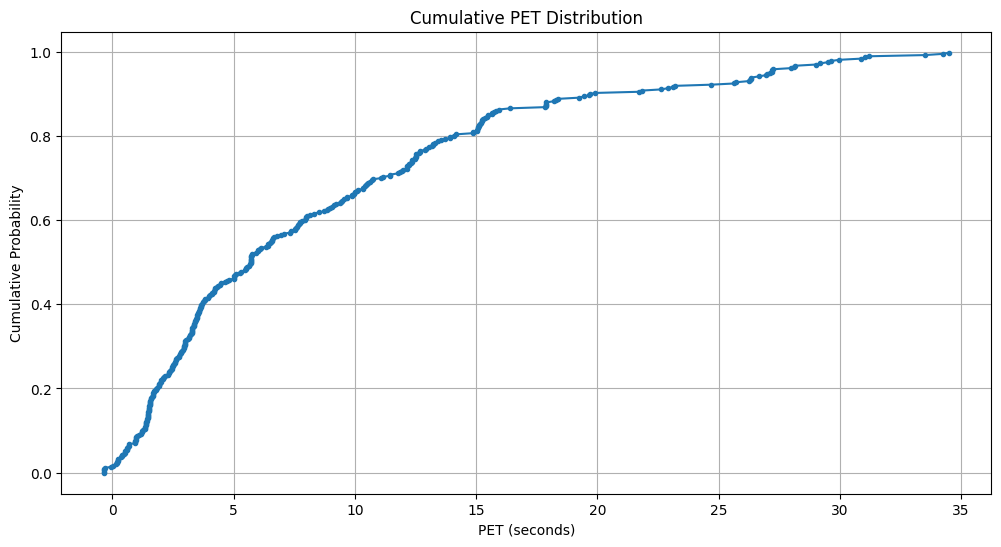

In [15]:
pet_sorted = pipeline.pet_df['pet'].sort_values()
cdf = np.arange(len(pet_sorted)) / len(pet_sorted)

plt.figure(figsize=(12, 6))

plt.plot(pet_sorted, cdf, marker='.', linestyle='-')
plt.xlabel('PET (seconds)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative PET Distribution')
plt.grid(True)
plt.show()

In [16]:
pipeline.df

,Time,Frame_ID,Vehicle_ID,X_central,Y_central,X1_boundary,Y1_boundary,X3_boundary,Y3_boundary,Conflict_Zone_ID,In_Conflict_Zone
0,0.000000,0,1,323.753850,244.54315,318.220580,239.55382,329.28710,249.53250,-1.0,False
1,0.000000,0,2,391.717830,275.67474,385.785250,270.32385,397.65040,281.02560,-1.0,False
2,0.000000,0,3,401.334100,251.35030,393.590270,244.73557,409.07790,257.96503,1.0,True
3,0.000000,0,4,522.845700,234.48148,511.184140,226.27820,534.50720,242.68474,10.0,True
4,0.033333,1,2,390.745000,275.69020,384.814150,270.33154,396.67587,281.04886,-1.0,False
...,...,...,...,...,...,...,...,...,...,...,...
6615,45.200000,1356,412,55.835953,304.38287,48.771217,298.37247,62.90069,310.39328,140.0,True
6616,45.200000,1356,402,293.596000,285.93573,287.697360,280.71014,299.49463,291.16132,119.0,True
6617,45.200000,1356,357,137.816040,297.97516,131.803470,292.35928,143.82863,303.59103,132.0,True
6618,45.200000,1356,360,759.087300,240.51747,749.301150,234.02133,768.87340,247.01361,-1.0,False


In [17]:
heatmap

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [18]:
video_path = "/kaggle/input/0212-cropped-video-cen300-45s/0212_cropped.mp4"
cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output_with_heatmap.mp4", fourcc, fps, (width, height))

normalized_heatmap = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX)
colored_heatmap = cv2.applyColorMap(normalized_heatmap.astype(np.uint8), cv2.COLORMAP_JET)

# === Step 4: Overlay on video frames ===
alpha = 0.6  # heatmap transparency

def draw_heatmap_legend(frame, x=20, y=5, width=20, height=20):
    legend_colors = {
    'Near-Miss': (0, 0, 255),         # Red
    'High Risk': (0, 69, 255),        # Orange-Red
    'Moderate Risk': (0, 255, 255),   # Yellow
    'Low Risk': (255, 255, 0),        # Cyan
    'Safe': (255, 0, 0)               # Blue
    }

    gap = height + 5  # vertical spacing
    start_y = y

    for label, color in legend_colors.items():
        end_y = start_y + height
        cv2.rectangle(frame, (x, start_y), (x + width, end_y), color, -1)
        cv2.putText(frame, label, (x + width + 10, start_y + height // 2 + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        start_y += gap

    return frame

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break


    if colored_heatmap.shape[:2] != frame.shape[:2]:
        colored_heatmap = cv2.resize(colored_heatmap, (frame.shape[1], frame.shape[0]))
    
    overlay = cv2.addWeighted(colored_heatmap, alpha, frame, 1 - alpha, 0)
    overlay = draw_heatmap_legend(overlay)  # Add legend after blending
    
    out.write(overlay)

cap.release()
out.release()
cv2.destroyAllWindows()